In [1]:
# import packages
import os
import pyproj
pyproj.datadir.set_data_dir('/srv/conda/envs/mintpy/share/proj')
os.environ["PROJ_DATA"]="/srv/conda/envs/mintpy/share/proj"
from glob import glob
import geopandas as gpd
from pathlib import Path
from typing import List, Union
from osgeo import gdal, gdal_array
import numpy as np
import matplotlib.pyplot as plt
import rioxarray
import xarray as xr
import rasterio as rio
import datetime
from datetime import datetime, timedelta
import sys
import gc
import pandas as pd
import seaborn as sns
from scipy.stats import linregress
from rasterio.enums import Resampling
from matplotlib.colors import LogNorm

sns.set_theme()

/srv/conda/envs/mintpy/lib/python3.11/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [2]:
# set up paths, directories, and variables for this specific dam
data_path = '/home/jovyan/repos/fufiters_imja_analysis/data'
asc_burst = '012_023790_IW1'
des_burst = '121_258661_IW2'
asc_burst_path = f'{data_path}/data_igrams/{asc_burst}'
des_burst_path = f'{data_path}/data_igrams/{des_burst}'

dam_name = 'imja'
proc_path = f'/home/jovyan/repos/fufiters_imja_analysis/analysis'

# define reference point, [y, x]
reference_point = [3086715.2, 491092.4]

# define crs 
crs = 32645

In [3]:
# read in dam polygon
dam_fn = f'../mapping/polygons/{dam_name}_md.shp'
dam_gdf = gpd.read_file(dam_fn)
dam_gdf = dam_gdf.to_crs(crs) # reproject in case of mistake

# load in moving area polygon
moving_fn = f'../mapping/polygons/{dam_name}_moving.shp'
moving_gdf = gpd.read_file(moving_fn)

# load in moving area polygon
reference_fn = f'../mapping/polygons/{dam_name}_reference.shp'
reference_gdf = gpd.read_file(reference_fn)

# load in stable area polygon
stable_fn = f'../mapping/polygons/{dam_name}_stable.shp'
stable_gdf = gpd.read_file(stable_fn).to_crs(crs)

# load in water mask
water_fn = f'../mapping/polygons/water_mask.shp'
water_gdf = gpd.read_file(water_fn).to_crs(crs)

# pad dam bounds by 5 km 
padding = 5000
aoi_extent = [dam_gdf.bounds.minx.item()-padding,
               dam_gdf.bounds.maxy.item()+padding,
               dam_gdf.bounds.maxx.item()+padding,
               dam_gdf.bounds.miny.item()-padding]

In [4]:
# functions to load interferogram tifs to xarray
def parse_file(file_path):
    data = {}
    with open(file_path, 'r') as file:
        for line in file:
            key, value = line.strip().split(': ')
            data[key] = value
    return data

def xr_read_geotif(geotif_file_path, masked=True):
    """
    Reads in single or multi-band GeoTIFF as dask array.
    Inputs
    ----------
    GeoTIFF_file_path : GeoTIFF file path
    Returns
    -------
    ds : xarray.Dataset
        Includes rioxarray extension to xarray.Dataset
    """

    da = rioxarray.open_rasterio(geotif_file_path, masked=True)

    # Extract bands and assign as variables in xr.Dataset()
    ds = xr.Dataset()
    for i, v in enumerate(da.band):
        da_tmp = da.sel(band=v)
        da_tmp.name = "band" + str(i + 1)

        ds[da_tmp.name] = da_tmp

    # Delete empty band coordinates.
    # Need to preserve spatial_ref coordinate, even though it appears empty.
    # See spatial_ref attributes under ds.coords.variables used by rioxarray extension.
    del ds.coords["band"]

    # Preserve top-level attributes and extract single value from value iterables e.g. (1,) --> 1
    ds.attrs = da.attrs
    for key, value in ds.attrs.items():
        try:
            if len(value) == 1:
                ds.attrs[key] = value[0]
        except TypeError:
            pass

    return ds

def hyp3_to_xarray(hyp3_dir, epsg, file_type='corr', interpolate_na=False):
    
    dirs = os.listdir(hyp3_dir) #list generated interferograms
    datasets = []
    acquisition_list = []
    
    for idir in dirs:
        tif_path = glob(f'{hyp3_dir}/{idir}/*/*{file_type}.tif')[0]
        tif_fn = os.path.split(tif_path)[-1]
        dates = f'{tif_fn[14:22]}_{tif_fn[23:31]}' #parse filename for interferogram dates
        start_date = datetime.strptime(dates[:8], '%Y%m%d')
        end_date = datetime.strptime(dates[-8:], '%Y%m%d')
        t_baseline = end_date - start_date
        middle_date = t_baseline/2+start_date
        
        src = xr_read_geotif(tif_path, masked=False) #read product to xarray ds
        src = src.assign_coords({"dates": dates})
        src = src.expand_dims("dates")
        
        src = src.assign_coords(start_date = ('dates', [start_date]))
        src = src.assign_coords(end_date = ('dates', [end_date]))
        src = src.assign_coords(t_baseline = ('dates', [t_baseline]))
        src = src.assign_coords(middle_date = ('dates', [middle_date]))
        
        src = src.rename({'band1':file_type})
        src = src.rio.write_crs(epsg)

        # open metadata file
        txt_path = glob(f'{hyp3_dir}/{idir}/*/*FFTS.txt')[0]
        meta_dict = parse_file(txt_path)
        src = src.assign_coords(perp_baseline = ('dates', [meta_dict['Baseline']]))
        
        if interpolate_na == True:
            src = src.interpolate_na(dim='x', method='linear').fillna(value=0)
        
        datasets.append(src)
        #print(src[file_type].shape, src.dates.item())
       
    ds = xr.concat(datasets, dim="dates", combine_attrs="no_conflicts") #create dataset
    ds = ds.sortby('dates')

    return ds 

In [5]:
asc_corr_ds = hyp3_to_xarray(asc_burst_path, crs, file_type=f'corr_{dam_name}')
des_corr_ds = hyp3_to_xarray(des_burst_path, crs, file_type=f'corr_{dam_name}')

In [7]:
# clip datasets to moving polygon
asc_dam_corr_ds = asc_corr_ds.rio.clip(moving_gdf.geometry.values, crs=moving_gdf.crs, drop=True)
des_dam_corr_ds = des_corr_ds.rio.clip(moving_gdf.geometry.values, crs=moving_gdf.crs, drop=True)

# clip datasets to stable polygon
asc_stable_corr_ds = asc_corr_ds.rio.clip(stable_gdf.geometry.values, crs=stable_gdf.crs, drop=True)
des_stable_corr_ds = des_corr_ds.rio.clip(stable_gdf.geometry.values, crs=stable_gdf.crs, drop=True)

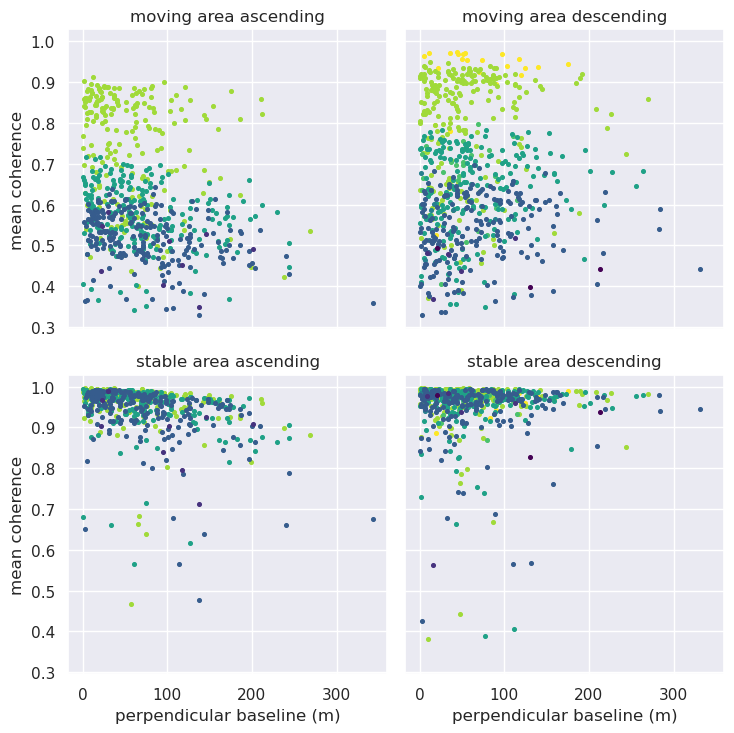

In [20]:
t_baselines = np.union1d(des_dam_corr_ds.t_baseline.dt.days.values, asc_dam_corr_ds.t_baseline.dt.days.values)

# plot seasonal changes in coherence 
colors = plt.cm.viridis_r(np.linspace(0, 1, len(t_baselines)))

f, ax = plt.subplots(2, 2, figsize=(7.5, 7.5), sharex=True, sharey=True, gridspec_kw={'height_ratios': [1, 1]})

for i, days in enumerate(t_baselines):
    ax[0, 0].scatter(np.fabs(asc_dam_corr_ds.perp_baseline[asc_dam_corr_ds.t_baseline.dt.days == days].astype('float32')),
                  asc_dam_corr_ds[f'corr_{dam_name}'].mean(dim=['x', 'y'])[asc_dam_corr_ds.t_baseline.dt.days == days],
                  color=colors[i],
                  s=7,
                  label=f'{int(days)} days')
    ax[0, 0].tick_params(left=False)

    ax[0, 1].scatter(np.fabs(des_dam_corr_ds.perp_baseline[des_dam_corr_ds.t_baseline.dt.days == days].astype('float32')),
                  des_dam_corr_ds[f'corr_{dam_name}'].mean(dim=['x', 'y'])[des_dam_corr_ds.t_baseline.dt.days == days],
                  color=colors[i],
                  s=7,
                  label=f'{int(days)} days')
    ax[0, 1].tick_params(left=False)

    ax[1, 0].scatter(np.fabs(asc_stable_corr_ds.perp_baseline[asc_stable_corr_ds.t_baseline.dt.days == days].astype('float32')),
                  asc_stable_corr_ds[f'corr_{dam_name}'].mean(dim=['x', 'y'])[asc_stable_corr_ds.t_baseline.dt.days == days],
                  color=colors[i],
                  s=7,
                  label=f'{int(days)} days')

    ax[1, 1].scatter(np.fabs(des_stable_corr_ds.perp_baseline[des_stable_corr_ds.t_baseline.dt.days == days].astype('float32')),
                  des_stable_corr_ds[f'corr_{dam_name}'].mean(dim=['x', 'y'])[des_stable_corr_ds.t_baseline.dt.days == days],
                  color=colors[i],
                  s=7,
                  label=f'{int(days)} days')

    ax[0, 0].set_ylabel('mean coherence')
    ax[1, 0].set_ylabel('mean coherence')
    ax[1, 0].set_xlabel('perpendicular baseline (m)')
    ax[1, 1].set_xlabel('perpendicular baseline (m)')
    ax[0, 0].set_title('moving area ascending')
    ax[0, 1].set_title('moving area descending')
    ax[1, 0].set_title('stable area ascending')
    ax[1, 1].set_title('stable area descending')
    #ax[1, 1].legend(loc='lower right', fontsize=10, ncol=2)

    
f.tight_layout()
plt.savefig(f'figs/imja_coherence_perp_baseline.png', dpi=300)

In [ ]:
# Function to fit a sine wave
def sine_function(t, amplitude, frequency, phase, offset):
    return amplitude * np.sin(2 * np.pi * frequency * t + phase) + offset

# Initial guess for the parameters
initial_guess = (0.3, 1/3.154e+16, 0.0, 0.0)

# Perform curve fitting
params_12, covariance_12 = curve_fit(sine_function, corr_12_ds.middle_date.values.astype(np.int64), corr_12_ds.corr_clipped.mean(dim=['x','y']).values, p0=initial_guess)
# Perform curve fitting
params_24, covariance_24 = curve_fit(sine_function, corr_24_ds.middle_date.values.astype(np.int64), corr_24_ds.corr_clipped.mean(dim=['x','y']).values, p0=initial_guess)

# Extract the fitted parameters
amplitude_12, frequency_12, phase_12, offset_12 = params_12
amplitude_24, frequency_24, phase_24, offset_24 = params_24

# Generate the fitted sine wave
fitted_sine_wave_12 = sine_function(corr_12_ds.middle_date.values.astype(np.int64), amplitude_12, frequency_12, phase_12, offset_12)
fitted_sine_wave_24 = sine_function(corr_24_ds.middle_date.values.astype(np.int64), amplitude_24, frequency_24, phase_24, offset_24)